<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/ConvLSTM_optimizations/TRIAL5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Dense, Flatten, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from datetime import timedelta
from sklearn.metrics import mean_absolute_error

# ================== CONFIG / CONSTANTS ==================
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.random.set_seed(42)
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60
N_TIMESTEPS = 14
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

LR = 0.0005
FILTERS = 128
EPOCHS = 50
BATCH_SIZE = 16

In [62]:
# ================== CUSTOM LOSS FUNCTIONS ==================
def smape_loss(y_true, y_pred, eps=1e-6):
    numer = tf.abs(y_pred - y_true)
    denom = tf.abs(y_true) + tf.abs(y_pred)
    denom = tf.where(denom < eps, eps, denom)
    return tf.reduce_mean(2.0 * numer / denom)

def direction_loss(y_true, y_pred):
    """Penalizes wrong prediction direction."""
    return tf.reduce_mean(tf.abs(tf.sign(y_true * y_pred) - 1))

def ultimate_ts_loss(y_true, y_pred, alpha_mae=0.3, alpha_huber=0.6, alpha_smape=0.2, alpha_dir=0.5, delta=1.0):
    mae = tf.reduce_mean(tf.abs(y_pred - y_true))
    diff = tf.abs(y_pred - y_true)
    huber = tf.reduce_mean(tf.where(diff <= delta, 0.5 * diff**2, delta * (diff - 0.5 * delta)))
    smape_val = smape_loss(y_true, y_pred)
    dir_loss = direction_loss(y_true, y_pred)
    return (alpha_mae * mae + alpha_huber * huber + alpha_smape * smape_val + alpha_dir * dir_loss)

class UltimateTSLoss(tf.keras.losses.Loss):
    def __init__(self, alpha_mae=0.3, alpha_huber=0.3, alpha_smape=0.2, alpha_dir=0.5, delta=1.0, name="ultimate_ts_loss"):
        super().__init__(name=name)
        self.alpha_mae = alpha_mae
        self.alpha_huber = alpha_huber
        self.alpha_smape = alpha_smape
        self.alpha_dir = alpha_dir
        self.delta = delta

    def call(self, y_true, y_pred):
        return ultimate_ts_loss(
            y_true, y_pred,
            alpha_mae=self.alpha_mae,
            alpha_huber=self.alpha_huber,
            alpha_smape=self.alpha_smape,
            alpha_dir=self.alpha_dir,
            delta=self.delta
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha_mae": self.alpha_mae,
            "alpha_huber": self.alpha_huber,
            "alpha_smape": self.alpha_smape,
            "alpha_dir": self.alpha_dir,
            "delta": self.delta
        })
        return config

In [63]:
# ================== HELPER FUNCTIONS ==================
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / np.where(denom == 0, 1, denom)
    return np.mean(diff) * 100

def build_convlstm_model(n_timesteps, n_features):
    model = Sequential([
        Input(shape=(n_timesteps, 1, n_features, 1)),
        ConvLSTM2D(filters=FILTERS, kernel_size=(1, 3), padding='same',
                   return_sequences=True, activation='tanh'),
        BatchNormalization(),
        ConvLSTM2D(filters=FILTERS//2, kernel_size=(1, 3), padding='same',
                   return_sequences=False, activation='tanh'),
        BatchNormalization(),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss=UltimateTSLoss(),   # <-- custom loss here
        metrics=['mae', smape_loss]
    )
    return model

def reshape_for_convlstm(X):
    return X.reshape((X.shape[0], X.shape[1], 1, X.shape[2], 1))

In [64]:
# ================== TRAINING LOGIC ==================
def train_and_plot_convlstm(df_center, center_name):
    df_center = df_center.sort_values('Date').reset_index(drop=True)
    for col in TARGET_RAW_COLS:
        for lag in [1, 7]:
            df_center[f'{col}_lag{lag}'] = df_center[col].shift(lag)
    df_center = df_center.fillna(0)

    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train = df_center[df_center['Date'] < test_start_date].copy()
    df_test = df_center[df_center['Date'] >= test_start_date].copy()

    feature_cols = [c for c in df_train.columns if c not in ['Date'] + TARGET_RAW_COLS]
    scaler_x = RobustScaler()
    X_train_scaled = scaler_x.fit_transform(df_train[feature_cols])
    X_test_scaled = scaler_x.transform(df_test[feature_cols])

    for target_col in TARGET_RAW_COLS:
        print(f"\n--- Training ConvLSTM for {center_name} - {target_col} ---")

        scaler_y = MinMaxScaler()
        y_train_scaled = scaler_y.fit_transform(df_train[[target_col]]).flatten()

        # Build training sequences
       # Build training sequences
        X_seq_train, y_seq_train = [], []
        for i in range(len(X_train_scaled) - N_TIMESTEPS):
            X_seq_train.append(X_train_scaled[i:i+N_TIMESTEPS])
            y_seq_train.append(y_train_scaled[i+N_TIMESTEPS])

        X_seq_train = np.array(X_seq_train)
        y_seq_train = np.array(y_seq_train)

        X_seq_train_5d = reshape_for_convlstm(X_seq_train)

        # Train model
        model = build_convlstm_model(N_TIMESTEPS, X_seq_train.shape[2])
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        history = model.fit(X_seq_train_5d, np.array(y_seq_train),
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            verbose=1, validation_split=0.1,
                            callbacks=[early_stop])

        # Plot training loss
        plt.figure(figsize=(10,4))
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(f'Loss Convergence: {target_col}')
        plt.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.show()

        # Build test sequences
        X_combined = np.vstack([X_train_scaled[-N_TIMESTEPS:], X_test_scaled])
        X_seq_test = [X_combined[i:i+N_TIMESTEPS] for i in range(len(X_combined)-N_TIMESTEPS)]
        X_seq_test_5d = reshape_for_convlstm(np.array(X_seq_test))

        # Predict and inverse transform
        y_preds_scaled = model.predict(X_seq_test_5d).flatten()
        y_preds = scaler_y.inverse_transform(y_preds_scaled.reshape(-1,1)).flatten()

        # Align lengths
        min_len = min(len(df_test), len(y_preds))
        y_true = df_test[target_col].iloc[:min_len].values
        y_pred = y_preds[:min_len]
        dates = df_test['Date'].iloc[:min_len]

        # Plot actual vs predicted
        plt.figure(figsize=(12,5))
        plt.plot(dates, y_true, label='Actual', color='blue')
        plt.plot(dates, y_pred, label='Predicted', color='orange', linestyle='--')
        plt.title(f"{center_name} Forecast: {target_col}")
        plt.legend(); plt.show()

        # Residual plot
        residuals = y_true - y_pred
        plt.figure(figsize=(12,4))
        plt.plot(dates, residuals, marker='o', linestyle='-', alpha=0.7)
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"Residuals Over Time: {target_col}")
        plt.show()

        # Print summary metrics
        print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
        print(f"SMAPE: {smape(y_true, y_pred):.2f}%")


--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_BreakFast ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 286ms/step - loss: 1.5667 - mae: 1.4713 - smape_loss: 1.7747 - val_loss: 0.2130 - val_mae: 0.1764 - val_smape_loss: 0.7343
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1.0260 - mae: 0.6773 - smape_loss: 1.6214 - val_loss: 0.1388 - val_mae: 0.1341 - val_smape_loss: 0.4700
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.9060 - mae: 0.4132 - smape_loss: 1.5747 - val_loss: 1.5227 - val_mae: 0.3972 - val_smape_loss: 1.9987
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.8119 - mae: 0.4142 - smape_loss: 1.3965 - val_loss: 1.6906 - val_mae: 0.7070 - val_smape_loss: 2.0000
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.4103 - mae: 0.2408 - smape_loss: 1.1070 - val_loss: 0.4164 - val_mae: 0.1872 - val_smape_loss: 1.0806
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3569 - mae: 0.1060 - smape_loss: 0.9104 - val_loss:

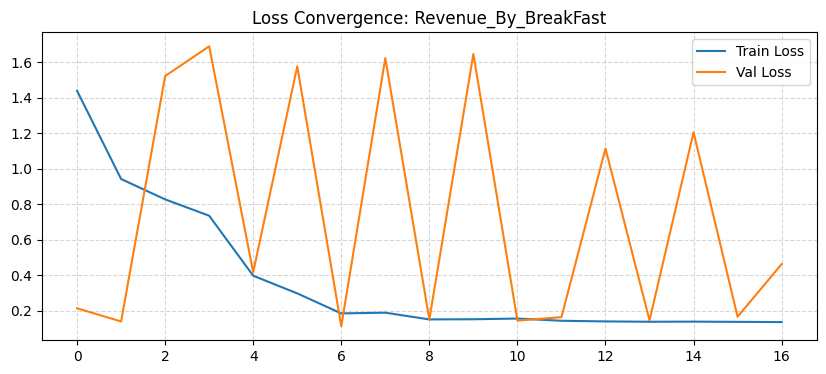

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step


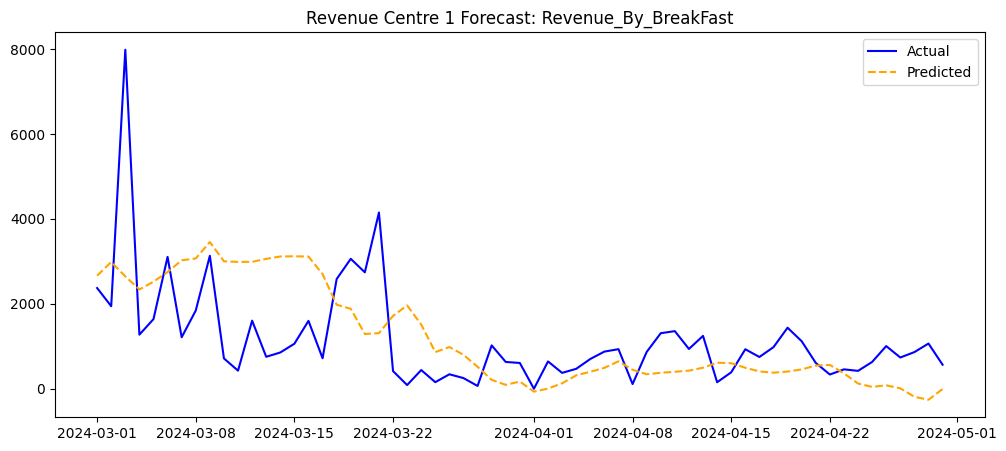

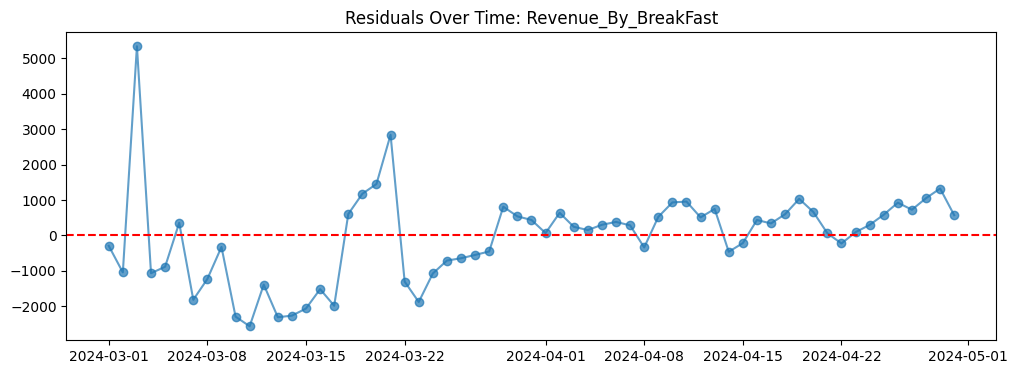

MAE: 964.93
SMAPE: 98.14%

--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_Dinner ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 277ms/step - loss: 1.4023 - mae: 1.3004 - smape_loss: 1.6090 - val_loss: 0.4727 - val_mae: 0.4293 - val_smape_loss: 1.5472
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.7632 - mae: 0.5938 - smape_loss: 1.2615 - val_loss: 0.3135 - val_mae: 0.3262 - val_smape_loss: 0.9541
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5999 - mae: 0.4170 - smape_loss: 1.1579 - val_loss: 0.8389 - val_mae: 0.4703 - val_smape_loss: 1.7422
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2692 - mae: 0.1842 - smape_loss: 0.7689 - val_loss: 0.2015 - val_mae: 0.2397 - val_smape_loss: 0.5833
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2014 - mae: 0.1353 - smape_loss: 0.6724 - val_loss: 0.7875 - val_mae: 0.4664 - val_smape_loss: 1.7293
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.1535 - mae: 0.1074 - smape_l

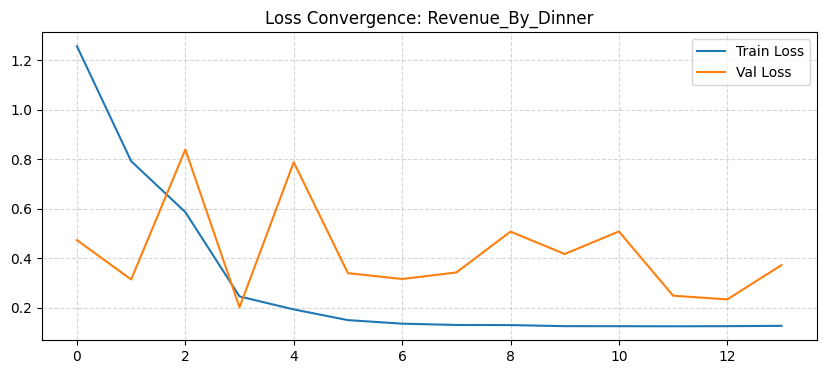

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


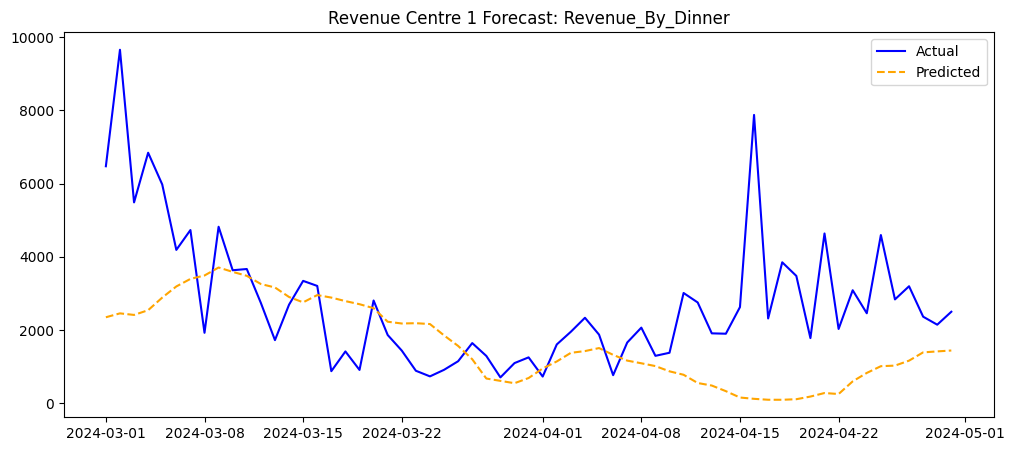

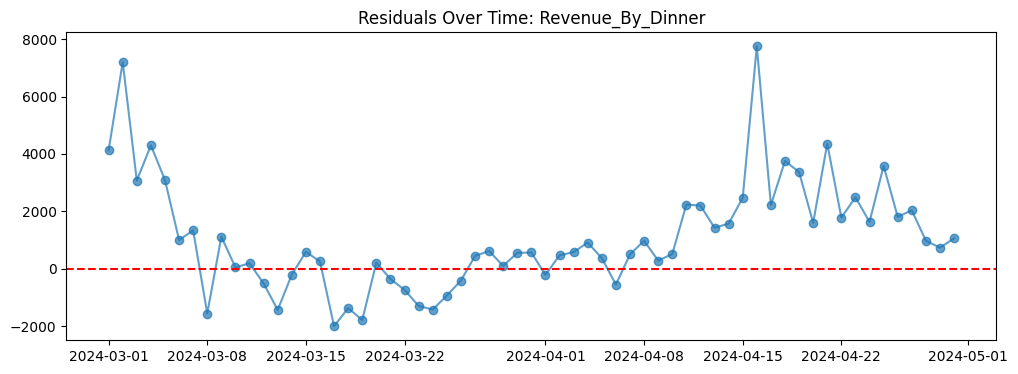

MAE: 1594.07
SMAPE: 74.99%

--- Training ConvLSTM for Revenue Centre 1 - Revenue_By_Lunch ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 265ms/step - loss: 1.5203 - mae: 1.5560 - smape_loss: 1.7178 - val_loss: 0.2160 - val_mae: 0.2167 - val_smape_loss: 0.7174
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.8961 - mae: 0.5693 - smape_loss: 1.4561 - val_loss: 1.6253 - val_mae: 0.5652 - val_smape_loss: 2.0000
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.6602 - mae: 0.3155 - smape_loss: 1.3144 - val_loss: 0.1870 - val_mae: 0.2012 - val_smape_loss: 0.6160
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.5159 - mae: 0.2925 - smape_loss: 1.0872 - val_loss: 0.4884 - val_mae: 0.2818 - val_smape_loss: 1.0882
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2990 - mae: 0.1356 - smape_loss: 0.8710 - val_loss: 0.2179 - val_mae: 0.2627 - val_smape_loss: 0.6616
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2112 - mae: 0.1020 - smape_l

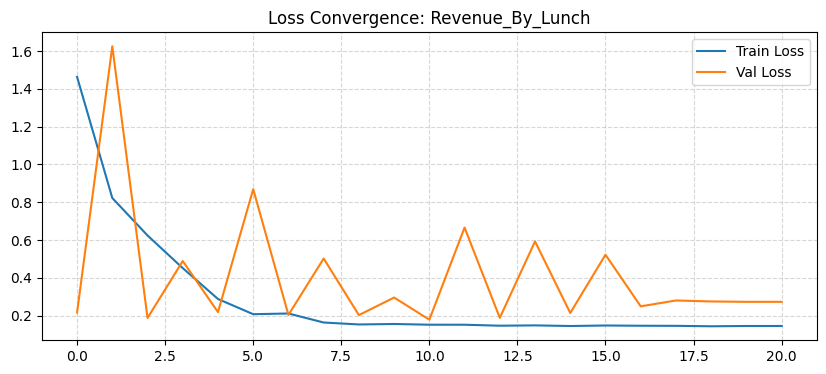

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


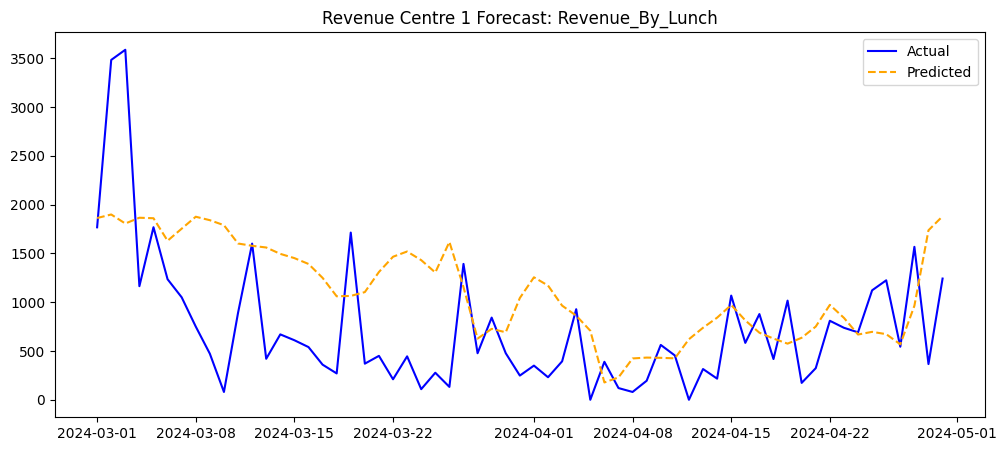

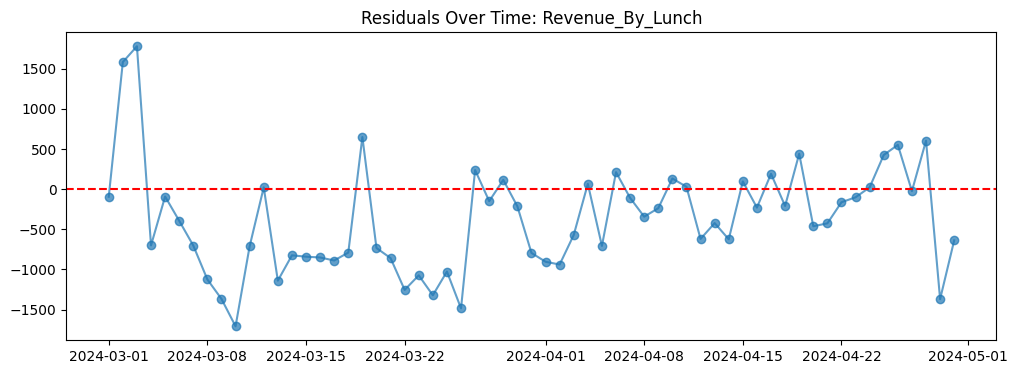

MAE: 613.42
SMAPE: 74.24%


In [65]:
try:
    df = pd.read_excel(INPUT_FILE_NAME, sheet_name=0)
    df['Date'] = pd.to_datetime(df['Date'])
    train_and_plot_convlstm(df, "Revenue Centre 1")
except Exception as e:
    print(f"Error: {e}")